In [40]:
import xml.etree.ElementTree as ET
import pandas as pd
import requests

page = 1
perPage = 1667  # 모든 데이터의 최대 페이지 수
merged_data = {}

# API 목록
api = [
    'uddi:99771417-a036-46f1-8ad5-8edf4591c2ee',  # 2020
    'uddi:b3803d43-ffe3-4d17-9024-fd6cfa37c284',  # 2021
    'uddi:75461a18-17a3-42fe-9322-a51148003b69',  # 2022
    'uddi:e477f1d9-2c3a-4dc8-b147-a55584583fa2',  # 2023
    'uddi:c87b6af0-0ef7-4182-b172-fd2680a79d6f',  # 2024/03
    'uddi:9aff0ee6-26e7-42c4-af0c-84bf31680ca9'  # 2024/06
    #'uddi:da7cd08f-94f0-4dba-b33d-d02dcb35b57b',  # 2024/09 데이터오류
]

# 각 년도의 데이터를 딕셔너리에 저장
for uddi in api:
    url = 'https://api.odcloud.kr/api/15071311/v1/' + uddi
    params = {
        'serviceKey': '9bi5h25Oa1d6yB2qd+7vNhE7qWLhgJvDSr4dTv6vhlZ3rvlpNTbs6NZv/B+R/CvFLssD7Flh+jSDAYydOoaRfQ==',
        'returnType': 'XML',
        'page': page,
        'perPage': perPage
    }
    try:
        response = requests.get(url, params=params)
        response.raise_for_status()  # API 요청 에러 처리
        data = {uddi: response.text}
        merged_data.update(data)
    except requests.exceptions.RequestException as e:
        print(f"API 요청 실패: {uddi}, 에러: {e}")

# XML 데이터를 순회하며 데이터프레임에 추가하는 함수
def parsing(data, year):
    xml_obj = ET.fromstring(data)
    rows = []

    for row in xml_obj.findall('.//item'):
        row_data = {}
        for col in row.findall('.//col'):
            if col.attrib['name'] == "조사일자":
                row_data['요일구분'] = col.text  # 조사일자 -> 요일구분
            elif col.attrib['name'] == "구분":
                row_data['상하구분'] = col.text  # 구분 -> 상하구분
            else:
                row_data[col.attrib['name']] = col.text  # 그 외의 경우 일반적으로 처리
        if row_data:
            rows.append(row_data)

    # 컬럼 매핑 딕셔너리
    column_list = ['년도', '호선', '상하구분', '역명', '역번호', '요일구분', '5시30분', '6시00분', '6시30분', '7시00분', '7시30분', '8시00분',
                   '8시30분', '9시00분', '9시30분', '10시00분', '10시30분', '11시00분', '11시30분', '12시00분', '12시30분', '13시00분',
                   '13시30분', '14시00분', '14시30분', '15시00분', '15시30분', '16시00분', '16시30분', '17시00분', '17시30분', '18시00분',
                   '18시30분', '19시00분', '19시30분', '20시00분', '20시30분', '21시00분', '21시30분', '22시00분', '22시30분', '23시00분',
                   '23시30분', '24시00분', '24시30분']
    column_mapping = {
        '년도': 'year', '호선': 'line', '상하구분': 'direction', '역명': 'station_name', '역번호': 'station_id', '요일구분': 'day_type',
        '5시30분': '5:30', '6시00분': '6:00', '6시30분': '6:30', '7시00분': '7:00', '7시30분': '7:30', '8시00분': '8:00',
        '8시30분': '8:30', '9시00분': '9:00', '9시30분': '9:30', '10시00분': '10:00', '10시30분': '10:30', '11시00분': '11:00',
        '11시30분': '11:30', '12시00분': '12:00', '12시30분': '12:30', '13시00분': '13:00', '13시30분': '13:30', '14시00분': '14:00',
        '14시30분': '14:30', '15시00분': '15:00', '15시30분': '15:30', '16시00분': '16:00', '16시30분': '16:30', '17시00분': '17:00',
        '17시30분': '17:30', '18시00분': '18:00', '18시30분': '18:30', '19시00분': '19:00', '19시30분': '19:30', '20시00분': '20:00',
        '20시30분': '20:30', '21시00분': '21:00', '21시30분': '21:30', '22시00분': '22:00', '22시30분': '22:30', '23시00분': '23:00',
        '23시30분': '23:30', '24시00분': '24:00', '24시30분': '24:30',
    }

    # DataFrame 생성 및 컬럼 이름 변경
    df = pd.DataFrame(rows, columns=column_list)

    df = df.rename(columns=column_mapping)

    # 'year' 컬럼 추가
    df['year'] = year
    return df

# 각 년도의 데이터를 데이터프레임으로 변환하고 병합
final_df = pd.DataFrame()  # 최종 데이터프레임을 위한 빈 데이터프레임

years = [2020, 2021, 2022, 2023, 202403, 202406]  # API에 해당하는 년도 목록
for uddi, year in zip(api, years):
    df = parsing(merged_data[uddi], year)  # 각 년도의 데이터를 파싱
    final_df = pd.concat([final_df, df], ignore_index=True)  # 데이터프레임 병합

# 데이터를 '시간'과 '혼잡도'로 변형
final_df_2 = pd.melt(final_df,
                      id_vars=['year', 'line', 'direction', 'station_name', 'station_id', 'day_type'],
                      var_name='time',
                      value_name='congestion')

final_df_2['congestion'] = final_df_2['congestion'].fillna(0)

# 기존 station_name과 station_id가 있는 DataFrame을 기준으로 매핑 생성
station_mapping = final_df_2.dropna(subset=['station_name']).set_index('station_id')['station_name'].to_dict()

# station_id를 기준으로 NaN 값을 station_name으로 채우기
final_df_2['station_name'] = final_df_2['station_name'].fillna(final_df_2['station_id'].map(station_mapping))

final_df_2.loc[final_df_2['station_id'] == '405', 'station_name'] = '전접'
final_df_2.loc[final_df_2['station_id'] == '406', 'station_name'] = '오남'
final_df_2.loc[final_df_2['station_id'] == '408', 'station_name'] = '별내별가람'
final_df_2 = final_df_2.drop(final_df_2[final_df_2['station_id'].isin(['2828','9001','9002','9003','9005','9006'])].index)
print(final_df_2)
final_df_2.to_csv('output_check.csv', index=False)

          year line direction station_name station_id day_type   time  \
0         2020    1        상선          서울역        150       평일   5:30   
1         2020    1        하선          서울역        150       평일   5:30   
2         2020    1        상선           시청        151       평일   5:30   
3         2020    1        하선           시청        151       평일   5:30   
4         2020    1        상선           종각        152       평일   5:30   
...        ...  ...       ...          ...        ...      ...    ...   
389722  202406    8        상선           신흥       2825      일요일  24:30   
389723  202406    8        하선           신흥       2825      일요일  24:30   
389724  202406    8        상선           수진       2826      일요일  24:30   
389725  202406    8        하선           수진       2826      일요일  24:30   
389726  202406    8        상선           모란       2827      일요일  24:30   

       congestion  
0             6.5  
1             9.0  
2             6.0  
3             7.1  
4             5.7  
...

In [41]:
# 데이터를 '시간'과 '혼잡도'로 변형
final_df_2 = pd.melt(final_df,
                      id_vars=['year', 'line', 'direction', 'station_name', 'station_id', 'day_type'],
                      var_name='time',
                      value_name='congestion')

final_df_2['congestion'] = final_df_2['congestion'].fillna(0)

# 기존 station_name과 station_id가 있는 DataFrame을 기준으로 매핑 생성
station_mapping = final_df_2.dropna(subset=['station_name']).set_index('station_id')['station_name'].to_dict()

# station_id를 기준으로 NaN 값을 station_name으로 채우기
final_df_2['station_name'] = final_df_2['station_name'].fillna(final_df_2['station_id'].map(station_mapping))


In [ ]:
# 역번호로 역명 찾기 함수
def get_station_name(station_number):
    result = final_df_2.loc[final_df_2['역번호'] == station_number, '역명']
    if not result.empty:
        return result.values[0]  # 역명 반환
    else:
        return "해당 역번호에 대한 역명이 없습니다."
        # 역명으로 역번호 찾기 함수
def get_station_number(station_name):
    result = final_df_2.loc[final_df_2['역명'] == station_name, '역번호']
    if not result.empty:
        return result.values[0]  # 역번호 반환
    else:
        return "해당 역명에 대한 역번호가 없습니다."

In [ ]:
print(get_station_number("서울역"))
print(get_station_name("2555"))

150


In [42]:
#역이름이 NaN인 역번호 출력
#9000번 역번호는 어떤번호인지 알수 없음
#2828 8호선 828 존재하지 않음 827번이 종착역인 모란역
#405 406 408 은 4호선 진접역 오남역 별내별가람역
result = pd.unique(final_df_2[final_df_2['station_name'].isnull()]['station_id'])

print(result)

['2828' '405' '406' '408' '9001' '9002' '9003' '9005' '9006']


In [30]:
#2024년 데이터에 있는 이상한  line 번호
result = final_df_2['line'].unique()
print(result)

['1' '2' '3' '4' '5' '6' '7' '8' '13' '14' '15']


In [39]:
#잘못된 라인 찾기
ndck = final_df_2[final_df_2['line'].isin(["13","14","15"])]
print(ndck[['station_name', 'line']].drop_duplicates())

     station_name line
1773           용답   13
1775           신답   13
1777          신설동   13
1779          도림천   14
1781         양천구청   14
1783        신정네거리   14
1785           용두   13
1787          까치산   14
1997          둔촌동   15
1999  올림픽공원(한국체대)   15
2001           방이   15
2003           오금   15
2005           개롱   15
2007           거여   15
2009           마천   15


In [44]:
#13, 14, 15호선을 각각 2, 5로 변환
final_df_2.loc[final_df_2['line'] == '13', 'line'] = '2'
final_df_2.loc[final_df_2['line'] == '14', 'line'] = '2'
final_df_2.loc[final_df_2['line'] == '15', 'line'] = '5'

2021년 데이터만 있음
용답 - 2호선
신답 - 2호선 (성수지선)
신설동 - 1호선, 2호선, 우이신설선
도림천 - 2호선 (신정지선)
양천구청 - 2호선 (신정지선)
신정네거리 - 2호선 (신정지선)
용두 - 2호선 (성수지선)
까치산 - 2호선, 5호선

둔촌동 - 5호선
올림픽공원(한국체대) - 5호선, 9호선
방이 - 5호선
오금 - 3호선, 5호선
개롱 - 5호선
거여 - 5호선
마천 - 5호선 (마천지선)

In [ ]:
final_df_2.loc[final_df_2['station_id'] == '405', 'station_name'] = '전접'
final_df_2.loc[final_df_2['station_id'] == '406', 'station_name'] = '오남'
final_df_2.loc[final_df_2['station_id'] == '408', 'station_name'] = '별내별가람'
final_df_2 = final_df_2.drop(final_df_2[final_df_2['station_id'].isin(['2828','9001','9002','9003','9005','9006'])].index)

In [21]:
final_df_2.info()


<class 'pandas.core.frame.DataFrame'>
Index: 338414 entries, 0 to 341365
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   year          338414 non-null  int64 
 1   line          338414 non-null  object
 2   direction     338414 non-null  object
 3   station_name  338414 non-null  object
 4   station_id    338414 non-null  object
 5   day_type      338414 non-null  object
 6   time          338414 non-null  object
 7   congestion    338414 non-null  object
dtypes: int64(1), object(7)
memory usage: 23.2+ MB


In [ ]:
# 1호선부터 9호선까지 데이터프레임을 저장할 딕셔너리 초기화
station_data = {}

# 1호선부터 8호선까지 반복
for line in range(1, 9):
    # 각 호선에 해당하는 데이터 추출
    station_data[f'station_{line}'] = final_df_2.loc[final_df_2['line'] == str(line)]

    print(f"--- {line}호선 데이터 ---")
    print(station_data[f'station_{line}'])
    station_data[f'station_{line}'].to_csv(f'station_{line}.csv', index=False)
    print("\n")

In [ ]:
# 1호선부터 9호선까지 데이터프레임을 저장할 딕셔너리 초기화
station_data = {}

# 1호선부터 8호선까지 반복
for line in range(1, 9):
    # 각 호선에 해당하는 데이터 추출
    station_data[f'{line}'] = final_df_2.loc[final_df_2['line'] == str(line)]
    #congestion 컬럼 type 변환
    station_data[f'{line}']['congestion'] = station_data[f'{line}']['congestion'].astype('float64')
    #print(f"--- {line}호선 데이터 ---")
  #  print(station_data[f'station_{line}'])
    station_data[f'{line}'].to_csv(f'line_{line}.csv', index=False)
    #print("\n")

**여기부터 전처리 완료된 코드**

In [88]:
import xml.etree.ElementTree as ET
import pandas as pd
import requests

page = 1
perPage = 1667  # 모든 데이터의 최대 페이지 수
merged_data = {}

# API 목록
api = [
    'uddi:99771417-a036-46f1-8ad5-8edf4591c2ee',  # 2020
    'uddi:b3803d43-ffe3-4d17-9024-fd6cfa37c284',  # 2021
    'uddi:75461a18-17a3-42fe-9322-a51148003b69',  # 2022
    'uddi:e477f1d9-2c3a-4dc8-b147-a55584583fa2',  # 2023
    'uddi:c87b6af0-0ef7-4182-b172-fd2680a79d6f',  # 2024/03
    'uddi:9aff0ee6-26e7-42c4-af0c-84bf31680ca9'  # 2024/06
    #'uddi:da7cd08f-94f0-4dba-b33d-d02dcb35b57b',  # 2024/09 데이터오류
]

# 각 년도의 데이터를 딕셔너리에 저장
for uddi in api:
    url = 'https://api.odcloud.kr/api/15071311/v1/' + uddi
    params = {
        'serviceKey': '9bi5h25Oa1d6yB2qd+7vNhE7qWLhgJvDSr4dTv6vhlZ3rvlpNTbs6NZv/B+R/CvFLssD7Flh+jSDAYydOoaRfQ==',
        'returnType': 'XML',
        'page': page,
        'perPage': perPage
    }
    try:
        response = requests.get(url, params=params)
        response.raise_for_status()  # API 요청 에러 처리
        data = {uddi: response.text}
        merged_data.update(data)
    except requests.exceptions.RequestException as e:
        print(f"API 요청 실패: {uddi}, 에러: {e}")

# XML 데이터를 순회하며 데이터프레임에 추가하는 함수
def parsing(data, year):
    xml_obj = ET.fromstring(data)
    rows = []

    for row in xml_obj.findall('.//item'):
        row_data = {}
        for col in row.findall('.//col'):
            if col.attrib['name'] == "조사일자":
                row_data['요일구분'] = col.text  # 조사일자 -> 요일구분
            elif col.attrib['name'] == "구분":
                row_data['상하구분'] = col.text  # 구분 -> 상하구분
            else:
                row_data[col.attrib['name']] = col.text  # 그 외의 경우 일반적으로 처리
        if row_data:
            rows.append(row_data)

    # 컬럼 매핑 딕셔너리
    column_list = ['년도', '호선', '상하구분', '역명', '역번호', '요일구분', '5시30분', '6시00분', '6시30분', '7시00분', '7시30분', '8시00분',
                   '8시30분', '9시00분', '9시30분', '10시00분', '10시30분', '11시00분', '11시30분', '12시00분', '12시30분', '13시00분',
                   '13시30분', '14시00분', '14시30분', '15시00분', '15시30분', '16시00분', '16시30분', '17시00분', '17시30분', '18시00분',
                   '18시30분', '19시00분', '19시30분', '20시00분', '20시30분', '21시00분', '21시30분', '22시00분', '22시30분', '23시00분',
                   '23시30분', '24시00분', '24시30분']
    column_mapping = {
        '년도': 'year', '호선': 'line', '상하구분': 'direction', '역명': 'station_name', '역번호': 'station_id', '요일구분': 'day_type',
        '5시30분': '5:30', '6시00분': '6:00', '6시30분': '6:30', '7시00분': '7:00', '7시30분': '7:30', '8시00분': '8:00',
        '8시30분': '8:30', '9시00분': '9:00', '9시30분': '9:30', '10시00분': '10:00', '10시30분': '10:30', '11시00분': '11:00',
        '11시30분': '11:30', '12시00분': '12:00', '12시30분': '12:30', '13시00분': '13:00', '13시30분': '13:30', '14시00분': '14:00',
        '14시30분': '14:30', '15시00분': '15:00', '15시30분': '15:30', '16시00분': '16:00', '16시30분': '16:30', '17시00분': '17:00',
        '17시30분': '17:30', '18시00분': '18:00', '18시30분': '18:30', '19시00분': '19:00', '19시30분': '19:30', '20시00분': '20:00',
        '20시30분': '20:30', '21시00분': '21:00', '21시30분': '21:30', '22시00분': '22:00', '22시30분': '22:30', '23시00분': '23:00',
        '23시30분': '23:30', '24시00분': '24:00', '24시30분': '24:30',
    }

    # DataFrame 생성 및 컬럼 이름 변경
    df = pd.DataFrame(rows, columns=column_list)

    df = df.rename(columns=column_mapping)

    # 'year' 컬럼 추가
    df['year'] = year
    return df

# 각 년도의 데이터를 데이터프레임으로 변환하고 병합
final_df = pd.DataFrame()  # 최종 데이터프레임을 위한 빈 데이터프레임

years = [2020, 2021, 2022, 2023, 202403, 202406]  # API에 해당하는 년도 목록
for uddi, year in zip(api, years):
    df = parsing(merged_data[uddi], year)  # 각 년도의 데이터를 파싱
    final_df = pd.concat([final_df, df], ignore_index=True)  # 데이터프레임 병합

# 데이터를 '시간'과 '혼잡도'로 변형
final_df_2 = pd.melt(final_df,
                      id_vars=['year', 'line', 'direction', 'station_name', 'station_id', 'day_type'],
                      var_name='time',
                      value_name='congestion')

final_df_2['congestion'] = final_df_2['congestion'].fillna(0)

# 기존 station_name과 station_id가 있는 DataFrame을 기준으로 매핑 생성
station_mapping = final_df_2.dropna(subset=['station_name']).set_index('station_id')['station_name'].to_dict()

# station_id를 기준으로 NaN 값을 station_name으로 채우기
final_df_2['station_name'] = final_df_2['station_name'].fillna(final_df_2['station_id'].map(station_mapping))

final_df_2.loc[final_df_2['station_id'] == '405', 'station_name'] = '전접'
final_df_2.loc[final_df_2['station_id'] == '406', 'station_name'] = '오남'
final_df_2.loc[final_df_2['station_id'] == '408', 'station_name'] = '별내별가람'
final_df_2 = final_df_2.drop(final_df_2[final_df_2['station_id'].isin(['2828','9001','9002','9003','9005','9006'])].index)

#13, 14, 15호선을 각각 2, 5로 변환
final_df_2.loc[final_df_2['line'] == '13', 'line'] = '2'
final_df_2.loc[final_df_2['line'] == '14', 'line'] = '2'
final_df_2.loc[final_df_2['line'] == '15', 'line'] = '5'

# 1호선부터 9호선까지 데이터프레임을 저장할 딕셔너리 초기화
station_data = {}

# 1호선부터 8호선까지 반복
for line in range(1, 9):
    # 각 호선에 해당하는 데이터 추출
    station_data[f'{line}'] = final_df_2.loc[final_df_2['line'] == str(line)]
    #congestion 컬럼 type 변환
    station_data[f'{line}']['congestion'] = station_data[f'{line}']['congestion'].astype('float64')
    #print(f"--- {line}호선 데이터 ---")
  #  print(station_data[f'station_{line}'])
    station_data[f'{line}'].to_csv(f'line_{line}.csv', index=False)
    #print("\n")

<ipython-input-88-d86b2016f61f>:120: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  station_data[f'{line}']['congestion'] = station_data[f'{line}']['congestion'].astype('float64')
<ipython-input-88-d86b2016f61f>:120: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  station_data[f'{line}']['congestion'] = station_data[f'{line}']['congestion'].astype('float64')
<ipython-input-88-d86b2016f61f>:120: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

In [3]:
!pip install lightgbm==3.3.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.1 MB/s eta 0:00:00
  Attempting uninstall: lightgbm
    Found existing installation: lightgbm 4.5.0
    Uninstalling lightgbm-4.5.0:
      Successfully uninstalled lightgbm-4.5.0


In [4]:
!pip install xgboost==1.7.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 MB 6.1 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.1.2
    Uninstalling xgboost-2.1.2:
      Successfully uninstalled xgboost-2.1.2


In [18]:
!pip install keras==3.2.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 10.5 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 2.9.0
    Uninstalling keras-2.9.0:
      Successfully uninstalled keras-2.9.0


In [49]:
for line in range(1, 9):
  print(f"--- {line}호선 데이터 ---")
  print(station_data[f'{line}'])
    #print("\n")

--- 1호선 데이터 ---
          year line direction station_name station_id day_type   time  \
0         2020    1        상선          서울역        150       평일   5:30   
1         2020    1        하선          서울역        150       평일   5:30   
2         2020    1        상선           시청        151       평일   5:30   
3         2020    1        하선           시청        151       평일   5:30   
4         2020    1        상선           종각        152       평일   5:30   
...        ...  ...       ...          ...        ...      ...    ...   
389187  202406    1        하선           종각        152      일요일  24:30   
389188  202406    1        상선           시청        151      일요일  24:30   
389189  202406    1        하선           시청        151      일요일  24:30   
389190  202406    1        상선          서울역        150      일요일  24:30   
389191  202406    1        하선          서울역        150      일요일  24:30   

        congestion  
0              6.5  
1              9.0  
2              6.0  
3              7.1  
4 

In [50]:
print(station_data['1'])
station_data['1'].info()

          year line direction station_name station_id day_type   time  \
0         2020    1        상선          서울역        150       평일   5:30   
1         2020    1        하선          서울역        150       평일   5:30   
2         2020    1        상선           시청        151       평일   5:30   
3         2020    1        하선           시청        151       평일   5:30   
4         2020    1        상선           종각        152       평일   5:30   
...        ...  ...       ...          ...        ...      ...    ...   
389187  202406    1        하선           종각        152      일요일  24:30   
389188  202406    1        상선           시청        151      일요일  24:30   
389189  202406    1        하선           시청        151      일요일  24:30   
389190  202406    1        상선          서울역        150      일요일  24:30   
389191  202406    1        하선          서울역        150      일요일  24:30   

        congestion  
0              6.5  
1              9.0  
2              6.0  
3              7.1  
4              5.7

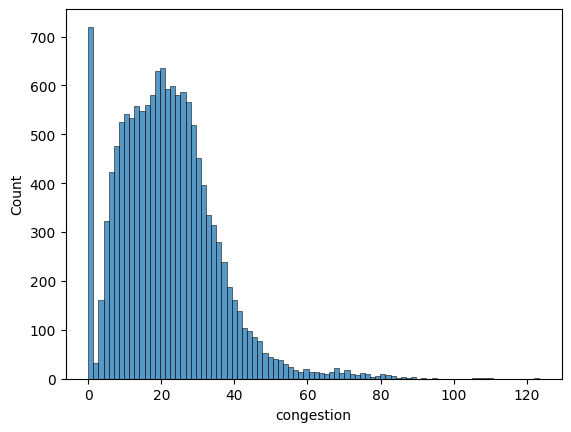

In [51]:
# 혼잡도 분포도
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.histplot(data=station_data['1'], x='congestion')
plt.show()

In [59]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from tensorflow import keras
from tensorflow.keras import layers

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [79]:
#1호선 학습
# 데이터를 독립변수(X)와 종속변수(y)로 나눕니다.
X = station_data['1'][['year', 'line', 'direction', 'station_name', 'day_type', 'time']]
y = station_data['1']['congestion']

# Replace '24:00' with '00:00' in the 'time' column and any other values greater than 23
X['time'] = X['time'].replace({'24:00': '00:00', '24:30': '00:30'})  # Add '24:30' replacement

# 'time' column to datetime and extract hour
# Use errors='coerce' to handle invalid time formats gracefully
X['time'] = pd.to_datetime(X['time'], format='%H:%M', errors='coerce').dt.hour

# Handle NaT values (if any) after conversion
X['time'] = X['time'].fillna(0).astype(int)  # Replace NaT with 0 and convert to int

# 데이터를 학습, 테스트 데이터로 나눕니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 범주형 열에 OneHot 인코딩을 적용
categorical_features = ['year', 'line', 'direction', 'station_name', 'day_type']
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='infrequent_if_exist', sparse_output=False))
])
#전처리
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features)],
    remainder='passthrough' ) #나머지 변수 유지


<ipython-input-79-d5ec4443d3b7>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['time'] = X['time'].replace({'24:00': '00:00', '24:30': '00:30'})  # Add '24:30' replacement
<ipython-input-79-d5ec4443d3b7>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['time'] = pd.to_datetime(X['time'], format='%H:%M', errors='coerce').dt.hour
<ipython-input-79-d5ec4443d3b7>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

In [80]:
#모델 정의
models = {
    "RF_reg": RandomForestRegressor(random_state=42),
    "Lin_reg": LinearRegression(),
    "XGB_reg": XGBRegressor(random_state=42),
    "LGB_reg": LGBMRegressor(random_state=42)
}

In [81]:
#파이프라인 구축
pipelines = {}
for model_name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        (model_name, model)
    ])
    pipelines[model_name] = pipeline


In [82]:
# 튜닝할 하이퍼파라미터 그리드 정의
param_dists = {
    'RF_reg': {
        'RF_reg__n_estimators': [100],
        'RF_reg__max_depth': [6, 8, 10, 12],
        'RF_reg__min_samples_split': [2, 5, 10]
    },
    'Lin_reg': {

    },
    'XGB_reg': {
        'XGB_reg__learning_rate': [0.01, 0.05, 0.1],
        'XGB_reg__n_estimators': [500],
        'XGB_reg__max_depth': [3, 5, 7],
        'XGB_reg__min_child_weight': [1, 5, 10],
        'XGB_reg__colsample_bytree': [1.0, 0.9, 0.8, 0.7],
        'XGB_reg__subsample': [1.0, 0.9, 0.8, 0.7],
        'XGB_reg__gamma': [0, 0.1, 0.2],
        'XGB_reg__alpha': [0, 0.01, 0.1],
        'XGB_reg__lambda': [0, 0.01, 0.1]
    },
    'LGB_reg': {
        'LGB_reg__learning_rate': [0.01, 0.05, 0.1],
        'LGB_reg__n_estimators': [500],
        'LGB_reg__max_depth': [6, 4, 8],
        'LGB_reg__colsample_bytree': [1.0, 0.9, 0.8, 0.7],
        'LGB_reg__subsample': [1.0, 0.9, 0.8, 0.7],
        'LGB_reg__min_child_samples': [20, 50, 100],
        'LGB_reg__reg_alpha': [0, 0.01, 0.1],
        'LGB_reg__reg_lambda': [0, 0.01, 0.1]
    }
}

1. Random Forest Regressor (RF_reg)
n_estimators: 생성할 결정 트리의 수입니다. 트리가 많을수록 모델의 일반화 능력이 향상되지만, 계산 비용이 증가합니다.
max_depth: 각 트리의 최대 깊이로, 과적합을 방지하는 데 도움을 줍니다. 깊이가 너무 깊으면 과적합이 발생할 수 있습니다.
min_samples_split: 내부 노드를 분할하는 데 필요한 최소 샘플 수로, 이 값이 커질수록 과적합이 줄어듭니다.

2. Linear Regression (Lin_reg)
선형 회귀는 일반적으로 하이퍼파라미터가 없지만, 규제(regularization) 방법을 적용하면 하이퍼파라미터가 생길 수 있습니다. 예를 들어 Lasso(라쏘) 또는 Ridge(릿지) 회귀에서 규제 강도를 조절하는 하이퍼파라미터가 있습니다.

3. XGBoost Regressor (XGB_reg)
learning_rate: 모델의 업데이트 속도로, 낮은 값은 더 세밀한 조정을 가능하게 하지만, 더 많은 트리를 필요로 할 수 있습니다.
n_estimators: 생성할 트리의 수로, 모델의 복잡도를 결정합니다.
max_depth: 트리의 깊이로, 과적합을 방지하는 데 도움을 줍니다.
min_child_weight: 자식 노드를 생성하기 위해 필요한 최소 가중치 합으로, 값이 높을수록 과적합을 줄입니다.
colsample_bytree: 각 트리를 훈련할 때 사용하는 특징의 비율입니다. 이 값이 낮으면 다양성이 증가하여 모델의 일반화가 향상될 수 있습니다.
subsample: 각 트리를 훈련할 때 사용할 샘플 비율로, 과적합을 줄이는 데 도움을 줍니다.
gamma, alpha, lambda: 각각 트리 가지치기, L1 및 L2 규제를 조절하는 파라미터로, 모델의 복잡도 및 일반화 성능을 조절합니다.

4. LightGBM Regressor (LGB_reg)
XGBoost와 유사한 하이퍼파라미터를 가지며, **min_child_samples**는 자식 노드를 생성하기 위해 필요한 최소 샘플 수를 지정합니다. 이 값을 조정하여 과적합을 방지할 수 있습니다.

In [83]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

results = {}
param_dist = param_dists['RF_reg']
pipeline = pipelines['RF_reg']
random_search = RandomizedSearchCV(estimator=pipeline, param_distributions=param_dist, n_iter=10, cv=3,
                                       scoring='neg_mean_squared_error', verbose=2, n_jobs=-1, random_state=42,
                                       return_train_score=True, refit=True)
random_search.fit(X_train, y_train)
results['RF_reg'] = random_search

# 각 모델별로 최적 모델 및 하이퍼파라미터 출력, 최적 모델 저장
best_model = results['RF_reg'].best_estimator_
best_params = results['RF_reg'].best_params_

print(f"모델: {model_name}")
print(f"최적 하이퍼파라미터: {best_params}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
모델: LGB_reg
최적 하이퍼파라미터: {'RF_reg__n_estimators': 100, 'RF_reg__min_samples_split': 5, 'RF_reg__max_depth': 12}


In [84]:
# 최적 모델 저장
#import joblib
#joblib.dump(best_model, 'RF_reg_num2.pkl')

# 테스트 데이터를 사용하여 모델의 성능을 평가합니다.
y_test_pred = best_model.predict(X_test)

# MAE, RMSE, Adjusted R2 Score 계산
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)
n = X_test.shape[0]
p = X_test.shape[1]
r2_test = r2_score(y_test, y_test_pred)
adjusted_r2_test = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)

# 결과를 출력합니다.
print("\nTest 성능 지표:")
print("Mean Absolute Error (MAE):", mae_test)
print("Root Mean Squared Error (RMSE):", rmse_test)
print("Adjusted R-squared (Adjusted R2):", adjusted_r2_test)
print('\n\n')


Test 성능 지표:
Mean Absolute Error (MAE): 3.385768367341842
Root Mean Squared Error (RMSE): 4.868691821215105
Adjusted R-squared (Adjusted R2): 0.8623379272761171





/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [85]:
param_dist = param_dists['Lin_reg']
pipeline = pipelines['Lin_reg']
random_search = RandomizedSearchCV(estimator=pipeline, param_distributions=param_dist, n_iter=10, cv=3,
                                       scoring='neg_mean_squared_error', verbose=2, n_jobs=-1, random_state=42,
                                       return_train_score=True, refit=True)
random_search.fit(X_train, y_train)
results['Lin_reg'] = random_search


# 각 모델별로 최적 모델 및 하이퍼파라미터 출력, 최적 모델 저장
best_model = results['Lin_reg'].best_estimator_
best_params = results['Lin_reg'].best_params_
moddel_name = 'Lin_reg'

print(f"모델: {model_name}")
print(f"최적 하이퍼파라미터: {best_params}")

# 최적 모델 저장
joblib.dump(best_model, 'Lin_reg_num2.pkl')

# 테스트 데이터를 사용하여 모델의 성능을 평가합니다.
y_test_pred = best_model.predict(X_test)

# MAE, RMSE, Adjusted R2 Score 계산
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)
n = X_test.shape[0]
p = X_test.shape[1]
r2_test = r2_score(y_test, y_test_pred)
adjusted_r2_test = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)

# 결과를 출력합니다.
print("\nTest 성능 지표:")
print("Mean Absolute Error (MAE):", mae_test)
print("Root Mean Squared Error (RMSE):", rmse_test)
print("Adjusted R-squared (Adjusted R2):", adjusted_r2_test)
print('\n\n')

Fitting 3 folds for each of 1 candidates, totalling 3 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


모델: LGB_reg
최적 하이퍼파라미터: {}

Test 성능 지표:
Mean Absolute Error (MAE): 8.65866173683554
Root Mean Squared Error (RMSE): 11.512887718266269
Adjusted R-squared (Adjusted R2): 0.2302348029110417





/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [86]:
param_dist = param_dists['LGB_reg']
pipeline = pipelines['LGB_reg']
random_search = RandomizedSearchCV(estimator=pipeline, param_distributions=param_dist, n_iter=10, cv=3,
                                       scoring='neg_mean_squared_error', verbose=2, n_jobs=-1, random_state=42,
                                       return_train_score=True, refit=True)
random_search.fit(X_train, y_train)
results['LGB_reg'] = random_search

# 각 모델별로 최적 모델 및 하이퍼파라미터 출력, 최적 모델 저장
best_model = results['LGB_reg'].best_estimator_
best_params = results['LGB_reg'].best_params_

print(f"모델: {model_name}")
print(f"최적 하이퍼파라미터: {best_params}")

# 최적 모델 저장
joblib.dump(best_model, 'LGB_reg_num2.pkl')

# 테스트 데이터를 사용하여 모델의 성능을 평가합니다.
y_test_pred = best_model.predict(X_test)

# MAE, RMSE, Adjusted R2 Score 계산
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)
n = X_test.shape[0]
p = X_test.shape[1]
r2_test = r2_score(y_test, y_test_pred)
adjusted_r2_test = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)

# 결과를 출력합니다.
print("\nTest 성능 지표:")
print("Mean Absolute Error (MAE):", mae_test)
print("Root Mean Squared Error (RMSE):", rmse_test)
print("Adjusted R-squared (Adjusted R2):", adjusted_r2_test)
print('\n\n')

Fitting 3 folds for each of 10 candidates, totalling 30 fits
모델: LGB_reg
최적 하이퍼파라미터: {'LGB_reg__subsample': 0.8, 'LGB_reg__reg_lambda': 0.01, 'LGB_reg__reg_alpha': 0.01, 'LGB_reg__n_estimators': 500, 'LGB_reg__min_child_samples': 20, 'LGB_reg__max_depth': 6, 'LGB_reg__learning_rate': 0.1, 'LGB_reg__colsample_bytree': 0.9}

Test 성능 지표:
Mean Absolute Error (MAE): 2.6182844102005354
Root Mean Squared Error (RMSE): 3.8560368265008376
Adjusted R-squared (Adjusted R2): 0.913648063915056





/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [87]:
param_dist = param_dists['XGB_reg']
pipeline = pipelines['XGB_reg']
random_search = RandomizedSearchCV(estimator=pipeline, param_distributions=param_dist, n_iter=10, cv=3,
                                       scoring='neg_mean_squared_error', verbose=2, n_jobs=-1, random_state=42,
                                       return_train_score=True, refit=True)
random_search.fit(X_train, y_train)
results['XGB_reg'] = random_search

# 각 모델별로 최적 모델 및 하이퍼파라미터 출력, 최적 모델 저장
best_model = results['XGB_reg'].best_estimator_
best_params = results['XGB_reg'].best_params_

print(f"모델: {model_name}")
print(f"최적 하이퍼파라미터: {best_params}")

# 최적 모델 저장
joblib.dump(best_model, 'XGB_reg_num2.pkl')

# 테스트 데이터를 사용하여 모델의 성능을 평가합니다.
y_test_pred = best_model.predict(X_test)

# MAE, RMSE, Adjusted R2 Score 계산
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)
n = X_test.shape[0]
p = X_test.shape[1]
r2_test = r2_score(y_test, y_test_pred)
adjusted_r2_test = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)

# 결과를 출력합니다.
print("\nTest 성능 지표:")
print("Mean Absolute Error (MAE):", mae_test)
print("Root Mean Squared Error (RMSE):", rmse_test)
print("Adjusted R-squared (Adjusted R2):", adjusted_r2_test)
print('\n\n')

Fitting 3 folds for each of 10 candidates, totalling 30 fits
모델: LGB_reg
최적 하이퍼파라미터: {'XGB_reg__subsample': 0.8, 'XGB_reg__n_estimators': 500, 'XGB_reg__min_child_weight': 10, 'XGB_reg__max_depth': 7, 'XGB_reg__learning_rate': 0.1, 'XGB_reg__lambda': 0.01, 'XGB_reg__gamma': 0.1, 'XGB_reg__colsample_bytree': 1.0, 'XGB_reg__alpha': 0.01}

Test 성능 지표:
Mean Absolute Error (MAE): 2.6578530598288106
Root Mean Squared Error (RMSE): 3.890798738524176
Adjusted R-squared (Adjusted R2): 0.9120841324145413





/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
